# Notebook 3 : Deep Learning — MLP & CNN

Ce notebook implémente des modèles de **Deep Learning** pour la classification des avis Yelp.

**Modèles :**
- **MLP** (Multi-Layer Perceptron) — sur TF-IDF et Embeddings SBERT
- **CNN** (Convolutional Neural Network) — avec couche d’embedding entraînable

**Tâches :**
- Classification de polarité (3 classes : positive, negative, neutral)
- Classification de rating (5 classes : 1–5 étoiles)

**Comparaison avec les résultats ML classique (Notebook 04)**

## 1. Imports et Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from collections import Counter

import sys
sys.path.insert(0, '..')

import pickle
import scipy.sparse

import os
import json
import time

from src.evaluation import evaluate_dl_model, load_results
from src.utils import encode_labels
from src.models import MLP, TextCNN

# Configuration
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if device.type == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

# Style des plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Chemin vers les features précalculées
FEATURES_DIR = '../data/precomputed'

print("Imports réussis")

Device : cpu
Imports réussis


## 2. Chargement et Preprocessing des Données

In [2]:
with open(f'{FEATURES_DIR}/train_test_split.pkl', 'rb') as f:
    splits = pickle.load(f)

X_train_text = splits['X_train']
X_test_text = splits['X_test']

print(f"Train : {len(X_train_text)} | Test : {len(X_test_text)}")
print(f"\nPolarité (train) : {splits['y_train_pol'].value_counts().to_dict()}")
print(f"Rating (train)   : {splits['y_train_rating'].value_counts().to_dict()}")

Train : 798328 | Test : 199583

Polarité (train) : {'positive': 535139, 'negative': 184373, 'neutral': 78816}
Rating (train)   : {5: 369277, 4: 165862, 1: 122333, 3: 78816, 2: 62040}


## 3. Encodage des Labels et Train/Test Split

In [3]:
# Encodage des labels avec la fonction utilitaire
y_train_pol, y_test_pol, le_polarity = encode_labels(splits['y_train_pol'], splits['y_test_pol'])
y_train_rating, y_test_rating, le_rating = encode_labels(splits['y_train_rating'], splits['y_test_rating'])

print(f"Classes polarité : {dict(zip(le_polarity.classes_, le_polarity.transform(le_polarity.classes_)))}")
print(f"Classes rating   : {dict(zip(le_rating.classes_, le_rating.transform(le_rating.classes_)))}")
print(f"\nTrain : {len(X_train_text)} | Test : {len(X_test_text)}")

Classes polarité : {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}
Classes rating   : {np.int64(1): np.int64(0), np.int64(2): np.int64(1), np.int64(3): np.int64(2), np.int64(4): np.int64(3), np.int64(5): np.int64(4)}

Train : 798328 | Test : 199583


## 4. Préparation des Représentations

On prépare trois types d'entrées pour nos modèles :
1. **TF-IDF** (vecteurs sparse → dense) pour le MLP
2. **Embeddings SBERT** (vecteurs denses 384-dim) pour le MLP
3. **Séquences de tokens** (indices de mots paddés) pour le CNN

### 4.1 TF-IDF

In [4]:
X_train_tfidf = scipy.sparse.load_npz(f'{FEATURES_DIR}/tfidf_train.npz')
X_test_tfidf = scipy.sparse.load_npz(f'{FEATURES_DIR}/tfidf_test.npz')

print(f"TF-IDF train shape : {X_train_tfidf.shape} (sparse, {X_train_tfidf.nnz:,} non-zero)")
print(f"TF-IDF test shape  : {X_test_tfidf.shape} (sparse, {X_test_tfidf.nnz:,} non-zero)")

TF-IDF train shape : (798328, 5000) (sparse, 30,658,264 non-zero)
TF-IDF test shape  : (199583, 5000) (sparse, 7,668,943 non-zero)


### 4.2 Embeddings SBERT

In [5]:
# Chargement embeddings SBERT précalculés (all-MiniLM-L6-v2, 384 dim)
X_train_emb = np.load(f'{FEATURES_DIR}/sbert_train.npy')
X_test_emb = np.load(f'{FEATURES_DIR}/sbert_test.npy')

print(f"Embeddings train shape : {X_train_emb.shape}")
print(f"Embeddings test shape  : {X_test_emb.shape}")

Embeddings train shape : (798328, 384)
Embeddings test shape  : (199583, 384)


### 4.3 Tokenisation pour le CNN

Le CNN travaille sur des **séquences de mots** (indices), pas des vecteurs agrégés.  
On construit un vocabulaire et on convertit chaque review en séquence d’indices avec padding.

In [6]:
MAX_VOCAB_SIZE = 25000
MAX_SEQ_LEN = 200

# Construire le vocabulaire sur le train set
word_counts = Counter()
for text in X_train_text:
    word_counts.update(text.split())

# Garder les mots les plus fréquents
vocab = {word: idx + 2 for idx, (word, _) in enumerate(word_counts.most_common(MAX_VOCAB_SIZE))}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1
VOCAB_SIZE = len(vocab)

print(f"Taille du vocabulaire : {VOCAB_SIZE}")
print(f"Longueur max des séquences : {MAX_SEQ_LEN}")

def text_to_sequence(text, vocab, max_len):
    """Convertit un texte en séquence d'indices avec padding."""
    tokens = text.split()
    indices = [vocab.get(w, 1) for w in tokens[:max_len]]
    if len(indices) < max_len:
        indices += [0] * (max_len - len(indices))
    return indices

X_train_seq = np.array([text_to_sequence(t, vocab, MAX_SEQ_LEN) for t in X_train_text])
X_test_seq = np.array([text_to_sequence(t, vocab, MAX_SEQ_LEN) for t in X_test_text])

print(f"Séquences train shape : {X_train_seq.shape}")
print(f"Séquences test shape  : {X_test_seq.shape}")
print(f"\nExemple de séquence (premiers 20 indices) : {X_train_seq[0][:20]}")

Taille du vocabulaire : 25002
Longueur max des séquences : 200
Séquences train shape : (798328, 200)
Séquences test shape  : (199583, 200)

Exemple de séquence (premiers 20 indices) : [ 39 286 470   1 291 109 287   7   2 605   1  28   1 188  20  52 438   3
 158  97]


## 5. Datasets & DataLoaders PyTorch

In [7]:
import scipy.sparse

class SparseDataset(Dataset):
    """Dataset pour matrices sparse scipy (TF-IDF). Convertit en dense ligne par ligne."""
    def __init__(self, sparse_matrix, labels):
        self.sparse_matrix = sparse_matrix.tocsr()
        self.labels = torch.tensor(labels.values, dtype=torch.long)
    
    def __len__(self):
        return self.sparse_matrix.shape[0]
    
    def __getitem__(self, idx):
        row = torch.tensor(self.sparse_matrix[idx].toarray().squeeze(0), dtype=torch.float32)
        return row, self.labels[idx]


class DenseDataset(Dataset):
    """Dataset pour arrays numpy denses (embeddings, séquences)."""
    def __init__(self, features, labels):
        if features.dtype == np.int64 or features.dtype == np.int32:
            self.features = torch.tensor(features, dtype=torch.long)
        else:
            self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels.values, dtype=torch.long)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


BATCH_SIZE = 512

# --- Datasets pour POLARITÉ ---
# TF-IDF (sparse)
train_tfidf_pol = DataLoader(SparseDataset(X_train_tfidf, y_train_pol), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_tfidf_pol  = DataLoader(SparseDataset(X_test_tfidf, y_test_pol), batch_size=BATCH_SIZE, num_workers=0)

# Embeddings (dense)
train_emb_pol = DataLoader(DenseDataset(X_train_emb, y_train_pol), batch_size=BATCH_SIZE, shuffle=True)
test_emb_pol  = DataLoader(DenseDataset(X_test_emb, y_test_pol), batch_size=BATCH_SIZE)

# Séquences (pour CNN)
train_seq_pol = DataLoader(DenseDataset(X_train_seq, y_train_pol), batch_size=BATCH_SIZE, shuffle=True)
test_seq_pol  = DataLoader(DenseDataset(X_test_seq, y_test_pol), batch_size=BATCH_SIZE)

# --- Datasets pour RATING ---
train_tfidf_rat = DataLoader(SparseDataset(X_train_tfidf, y_train_rating), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_tfidf_rat  = DataLoader(SparseDataset(X_test_tfidf, y_test_rating), batch_size=BATCH_SIZE, num_workers=0)

train_emb_rat = DataLoader(DenseDataset(X_train_emb, y_train_rating), batch_size=BATCH_SIZE, shuffle=True)
test_emb_rat  = DataLoader(DenseDataset(X_test_emb, y_test_rating), batch_size=BATCH_SIZE)

train_seq_rat = DataLoader(DenseDataset(X_train_seq, y_train_rating), batch_size=BATCH_SIZE, shuffle=True)
test_seq_rat  = DataLoader(DenseDataset(X_test_seq, y_test_rating), batch_size=BATCH_SIZE)

print(f"DataLoaders créés (batch_size={BATCH_SIZE})")
print(f"  TF-IDF   : sparse -> dense à la volée (par batch)")
print(f"  Polarité : {len(le_polarity.classes_)} classes")
print(f"  Rating   : {len(le_rating.classes_)} classes")

DataLoaders créés (batch_size=512)
  TF-IDF   : sparse -> dense à la volée (par batch)
  Polarité : 3 classes
  Rating   : 5 classes


## 6. Fonctions d’Entraînement et d’Évaluation

In [8]:
def train_model(model, train_loader, val_loader, epochs=20, lr=1e-3,
                class_weights=None, patience=5, min_delta=1e-4,
                grad_clip=1.0, warmup_epochs=2, weight_decay=1e-4):
    """
    Boucle d'entraînement avec EarlyStopping, gradient clipping et LR scheduling.
    
    Callbacks integres :
        - EarlyStopping : arret si pas d'amelioration de val_loss pendant `patience` epoques
        - ReduceLROnPlateau : reduit le LR si val_loss stagne (apres warmup)
        - Gradient Clipping : evite l'explosion des gradients
        - Model Checkpoint : sauvegarde le meilleur modele (base sur val_loss)
    """
    model.to(device)
    
    if class_weights is not None:
        criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    else:
        criterion = nn.CrossEntropyLoss()
    
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=2, factor=0.5, min_lr=1e-6
    )
    
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_val_acc = 0
    best_state = None
    epochs_no_improve = 0
    
    for epoch in range(epochs):
        # --- Train ---
        model.train()
        total_loss = 0
        n_batches = 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            
            optimizer.step()
            
            total_loss += loss.item()
            n_batches += 1
        
        avg_train_loss = total_loss / n_batches
        
        # --- Validation ---
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        n_val = 0
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                val_loss += criterion(outputs, y_batch).item()
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == y_batch).sum().item()
                total += y_batch.size(0)
                n_val += 1
        
        avg_val_loss = val_loss / n_val
        val_acc = correct / total
        
        # LR scheduling (apres warmup)
        if epoch >= warmup_epochs:
            scheduler.step(avg_val_loss)
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)
        
        # Model Checkpoint : sauvegarder le meilleur modele (base sur val_loss)
        if avg_val_loss < best_val_loss - min_delta:
            best_val_loss = avg_val_loss
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
            marker = " *"
        else:
            epochs_no_improve += 1
            marker = ""
        
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:2d}/{epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | "
              f"Val Acc: {val_acc:.4f} | "
              f"LR: {current_lr:.1e}{marker}")
        
        # EarlyStopping
        if epochs_no_improve >= patience:
            print(f"\nEarlyStopping : pas d'amelioration depuis {patience} epoques")
            break
    
    # Restaurer le meilleur modele
    if best_state is not None:
        model.load_state_dict(best_state)
    
    stopped_epoch = len(history['train_loss'])
    best_epoch = stopped_epoch - epochs_no_improve
    print(f"\nMeilleure Val Loss : {best_val_loss:.4f} | Val Acc : {best_val_acc:.4f} (epoque {best_epoch})")
    return history


def plot_training_history(history, title):
    """Affiche les courbes de loss et accuracy avec indication du meilleur epoch."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    best_epoch = np.argmin(history['val_loss'])
    
    # Loss
    axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
    axes[0].axvline(x=best_epoch, color='red', linestyle='--', alpha=0.7, label=f'Best (epoch {best_epoch+1})')
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1].plot(history['val_acc'], label='Val Accuracy', marker='o', color='green')
    axes[1].axvline(x=best_epoch, color='red', linestyle='--', alpha=0.7, label=f'Best (epoch {best_epoch+1})')
    axes[1].set_title(f'{title} - Validation Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

from sklearn.utils.class_weight import compute_class_weight as sklearn_class_weights

def compute_class_weights(labels, smoothing=0.5):
    """Poids lisses pour la polarite."""
    counts = np.bincount(labels.values)
    freq = counts / counts.sum()
    weights = (1.0 / freq) ** smoothing
    weights = weights / weights.sum() * len(counts)
    return torch.tensor(weights, dtype=torch.float32)

weights_pol = compute_class_weights(y_train_pol, smoothing=0.5)

weights_rat_np = sklearn_class_weights('balanced', classes=np.arange(5), y=y_train_rating.values)
weights_rat = torch.tensor(weights_rat_np, dtype=torch.float32)

print(f"Poids polarite (lisses)   : {weights_pol}")
print(f"Poids rating   (balanced) : {weights_rat}")

# Listes pour collecter les résultats de chaque modèle
results_pol = []
results_rat = []

print("\nFonctions d'evaluation definies")

Poids polarite (lisses)   : tensor([0.9626, 1.4723, 0.5650])
Poids rating   (balanced) : tensor([1.3052, 2.5736, 2.0258, 0.9626, 0.4324])

Fonctions d'evaluation definies


---
## 7. MLP (Multi-Layer Perceptron)

Réseau de neurones entièrement connecté (feedforward).  
On l’entraîne sur deux types d’entrées : **TF-IDF** et **Embeddings SBERT**.

In [9]:
print("Architecture MLP :")
print(MLP(5000, 3))

Architecture MLP :
MLP(
  (network): Sequential(
    (0): Linear(in_features=5000, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=3, bias=True)
  )
)


### 7.1 MLP + TF-IDF → Polarité

Parametres : 1,314,307
Epoch  1/25 | Train Loss: 0.5217 | Val Loss: 0.4428 | Val Acc: 0.8562 | LR: 5.0e-04 *
Epoch  2/25 | Train Loss: 0.4433 | Val Loss: 0.4363 | Val Acc: 0.8588 | LR: 5.0e-04 *
Epoch  3/25 | Train Loss: 0.4253 | Val Loss: 0.4359 | Val Acc: 0.8581 | LR: 5.0e-04 *
Epoch  4/25 | Train Loss: 0.4084 | Val Loss: 0.4360 | Val Acc: 0.8560 | LR: 5.0e-04
Epoch  5/25 | Train Loss: 0.3889 | Val Loss: 0.4403 | Val Acc: 0.8567 | LR: 5.0e-04
Epoch  6/25 | Train Loss: 0.3684 | Val Loss: 0.4505 | Val Acc: 0.8547 | LR: 2.5e-04
Epoch  7/25 | Train Loss: 0.3306 | Val Loss: 0.4726 | Val Acc: 0.8557 | LR: 2.5e-04
Epoch  8/25 | Train Loss: 0.3110 | Val Loss: 0.4813 | Val Acc: 0.8565 | LR: 2.5e-04

EarlyStopping : pas d'amelioration depuis 5 epoques

Meilleure Val Loss : 0.4359 | Val Acc : 0.8581 (epoque 3)


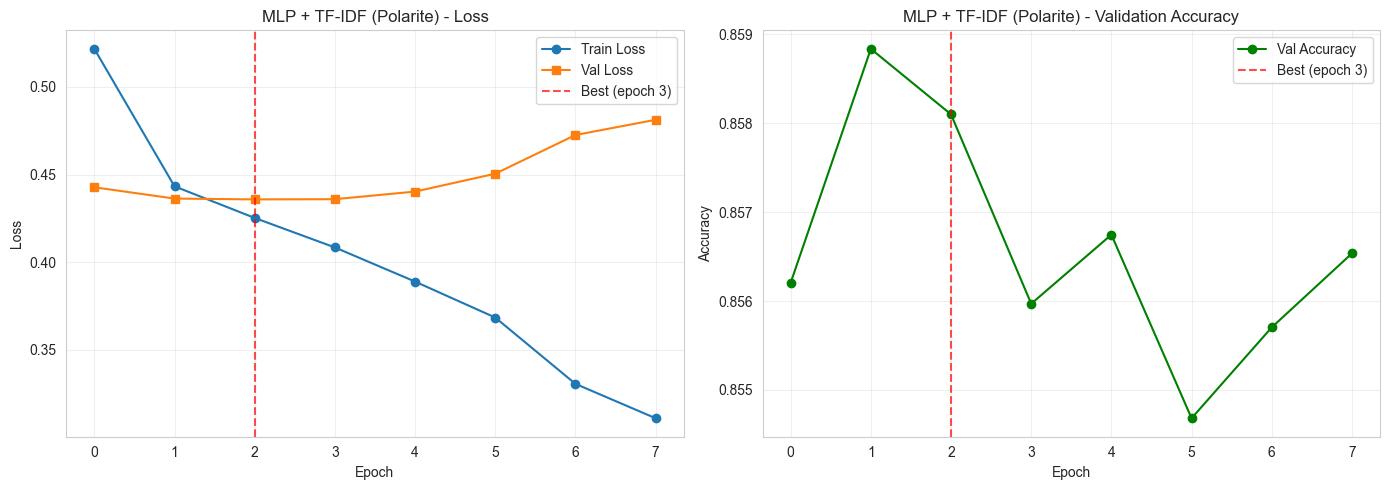


 MLP + TF-IDF
Accuracy:     0.8581
F1-macro:     0.7451
F1-weighted:  0.8627

              precision    recall  f1-score   support

    negative       0.82      0.87      0.85     46093
     neutral       0.43      0.50      0.46     19704
    positive       0.95      0.91      0.93    133786

    accuracy                           0.86    199583
   macro avg       0.73      0.76      0.75    199583
weighted avg       0.87      0.86      0.86    199583



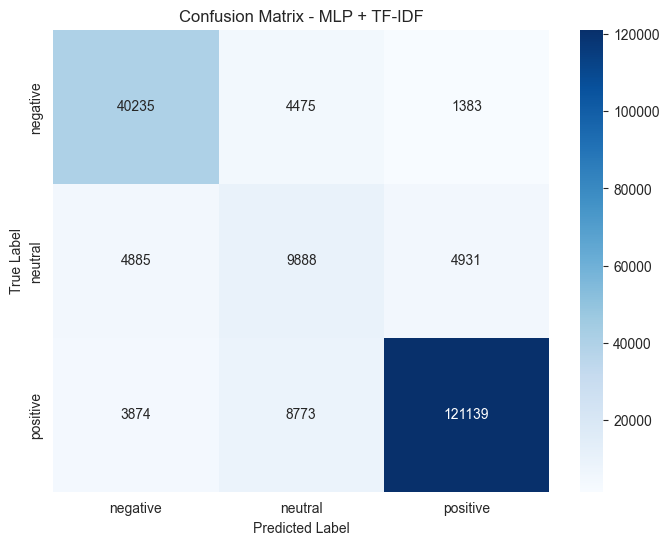

In [10]:
EPOCHS_MLP = 25

mlp_tfidf_pol = MLP(input_dim=5000, n_classes=3, hidden_dims=(256, 128), dropout=0.5)
print(f"Parametres : {sum(p.numel() for p in mlp_tfidf_pol.parameters()):,}")

history_mlp_tfidf_pol = train_model(
    mlp_tfidf_pol, train_tfidf_pol, test_tfidf_pol,
    epochs=EPOCHS_MLP, lr=5e-4, class_weights=weights_pol,
    patience=5, grad_clip=1.0
)

plot_training_history(history_mlp_tfidf_pol, "MLP + TF-IDF (Polarite)")
results_pol.append(evaluate_dl_model(mlp_tfidf_pol, test_tfidf_pol, le_polarity, "MLP + TF-IDF"))

### 7.2 MLP + Embeddings SBERT → Polarité

Parametres : 363,523
Epoch  1/25 | Train Loss: 0.5879 | Val Loss: 0.5224 | Val Acc: 0.8235 | LR: 5.0e-04 *
Epoch  2/25 | Train Loss: 0.5273 | Val Loss: 0.5055 | Val Acc: 0.8308 | LR: 5.0e-04 *
Epoch  3/25 | Train Loss: 0.5126 | Val Loss: 0.4972 | Val Acc: 0.8365 | LR: 5.0e-04 *
Epoch  4/25 | Train Loss: 0.5032 | Val Loss: 0.4918 | Val Acc: 0.8346 | LR: 5.0e-04 *
Epoch  5/25 | Train Loss: 0.4963 | Val Loss: 0.4883 | Val Acc: 0.8363 | LR: 5.0e-04 *
Epoch  6/25 | Train Loss: 0.4906 | Val Loss: 0.4853 | Val Acc: 0.8395 | LR: 5.0e-04 *
Epoch  7/25 | Train Loss: 0.4854 | Val Loss: 0.4826 | Val Acc: 0.8426 | LR: 5.0e-04 *
Epoch  8/25 | Train Loss: 0.4813 | Val Loss: 0.4804 | Val Acc: 0.8439 | LR: 5.0e-04 *
Epoch  9/25 | Train Loss: 0.4776 | Val Loss: 0.4807 | Val Acc: 0.8439 | LR: 5.0e-04
Epoch 10/25 | Train Loss: 0.4739 | Val Loss: 0.4797 | Val Acc: 0.8491 | LR: 5.0e-04 *
Epoch 11/25 | Train Loss: 0.4705 | Val Loss: 0.4780 | Val Acc: 0.8390 | LR: 5.0e-04 *
Epoch 12/25 | Train Loss: 0.4675 | 

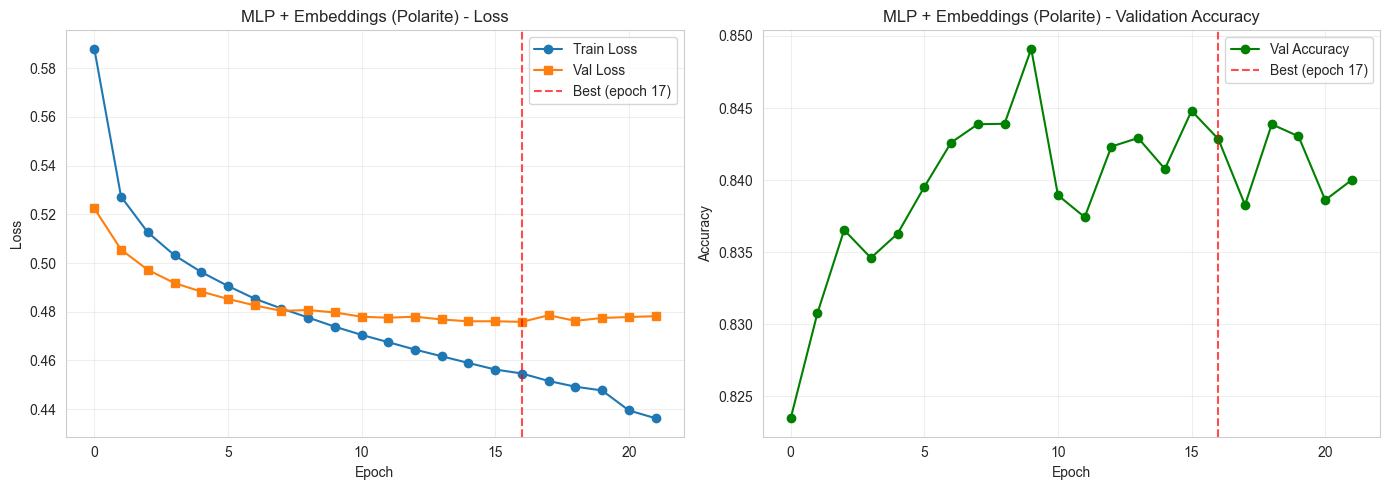


 MLP + Embeddings
Accuracy:     0.8429
F1-macro:     0.7268
F1-weighted:  0.8499

              precision    recall  f1-score   support

    negative       0.83      0.84      0.83     46093
     neutral       0.38      0.49      0.43     19704
    positive       0.94      0.90      0.92    133786

    accuracy                           0.84    199583
   macro avg       0.72      0.74      0.73    199583
weighted avg       0.86      0.84      0.85    199583



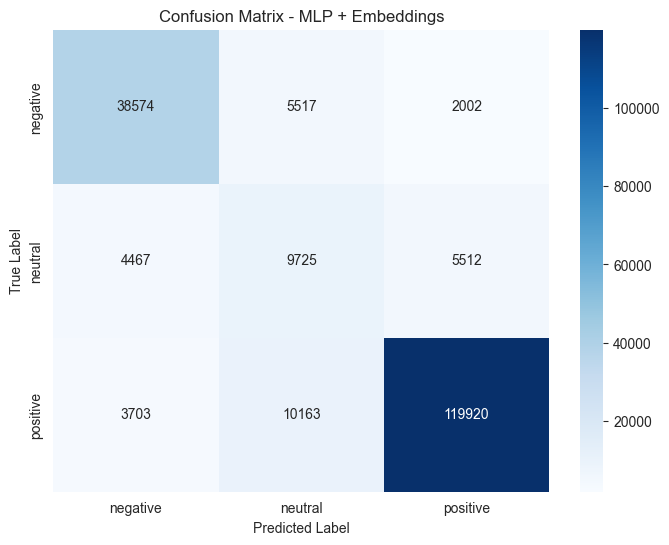

In [11]:
mlp_emb_pol = MLP(input_dim=384, n_classes=3, hidden_dims=(512, 256, 128), dropout=0.4)
print(f"Parametres : {sum(p.numel() for p in mlp_emb_pol.parameters()):,}")

history_mlp_emb_pol = train_model(
    mlp_emb_pol, train_emb_pol, test_emb_pol,
    epochs=EPOCHS_MLP, lr=5e-4, class_weights=weights_pol,
    patience=5, grad_clip=1.0
)

plot_training_history(history_mlp_emb_pol, "MLP + Embeddings (Polarite)")
results_pol.append(evaluate_dl_model(mlp_emb_pol, test_emb_pol, le_polarity, "MLP + Embeddings"))

### 7.3 MLP + TF-IDF → Rating

Parametres : 2,727,173
Epoch  1/25 | Train Loss: 0.9712 | Val Loss: 0.9032 | Val Acc: 0.6533 | LR: 1.0e-03 *
Epoch  2/25 | Train Loss: 0.8915 | Val Loss: 0.8981 | Val Acc: 0.6510 | LR: 1.0e-03 *
Epoch  3/25 | Train Loss: 0.8492 | Val Loss: 0.9028 | Val Acc: 0.6598 | LR: 1.0e-03
Epoch  4/25 | Train Loss: 0.7836 | Val Loss: 0.9277 | Val Acc: 0.6485 | LR: 1.0e-03
Epoch  5/25 | Train Loss: 0.6920 | Val Loss: 0.9963 | Val Acc: 0.6498 | LR: 1.0e-03
Epoch  6/25 | Train Loss: 0.5989 | Val Loss: 1.1007 | Val Acc: 0.6359 | LR: 5.0e-04
Epoch  7/25 | Train Loss: 0.4762 | Val Loss: 1.2676 | Val Acc: 0.6432 | LR: 5.0e-04
Epoch  8/25 | Train Loss: 0.4169 | Val Loss: 1.3814 | Val Acc: 0.6463 | LR: 5.0e-04
Epoch  9/25 | Train Loss: 0.3836 | Val Loss: 1.4824 | Val Acc: 0.6445 | LR: 2.5e-04

EarlyStopping : pas d'amelioration depuis 7 epoques

Meilleure Val Loss : 0.8981 | Val Acc : 0.6510 (epoque 2)


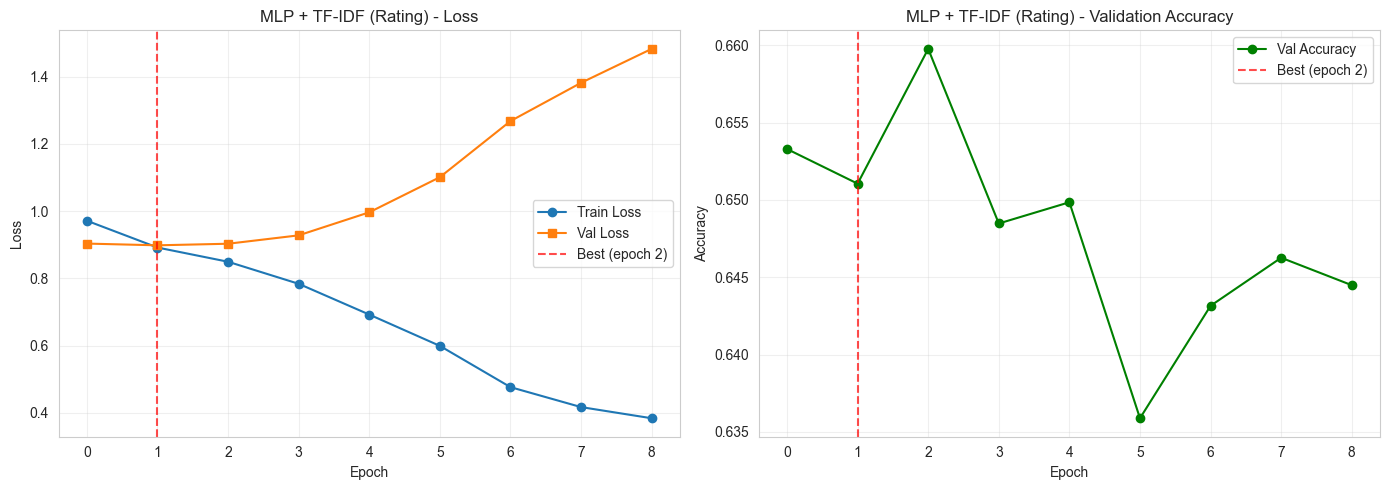


 MLP + TF-IDF
Accuracy:     0.6510
F1-macro:     0.5886
F1-weighted:  0.6631

              precision    recall  f1-score   support

           1       0.77      0.79      0.78     30583
           2       0.39      0.55      0.45     15510
           3       0.40      0.45      0.43     19704
           4       0.47      0.54      0.50     41466
           5       0.86      0.72      0.78     92320

    accuracy                           0.65    199583
   macro avg       0.58      0.61      0.59    199583
weighted avg       0.69      0.65      0.66    199583



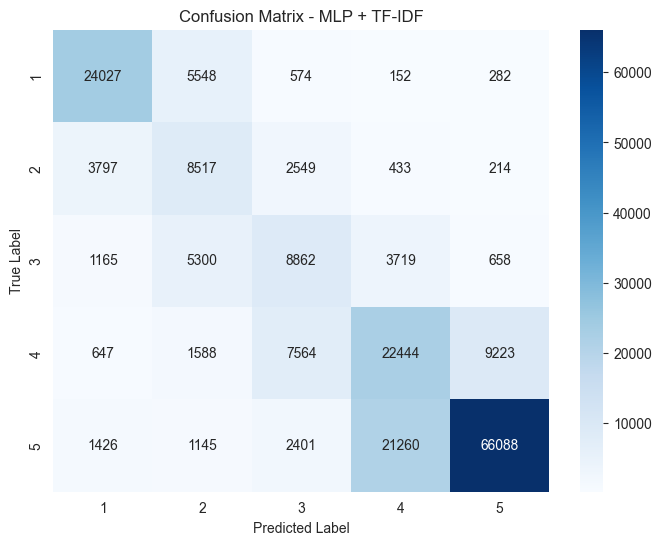

In [12]:
EPOCHS_MLP = 25

mlp_tfidf_rat = MLP(input_dim=5000, n_classes=5, hidden_dims=(512, 256, 128), dropout=0.3)
print(f"Parametres : {sum(p.numel() for p in mlp_tfidf_rat.parameters()):,}")

history_mlp_tfidf_rat = train_model(
    mlp_tfidf_rat, train_tfidf_rat, test_tfidf_rat,
    epochs=EPOCHS_MLP, lr=1e-3, class_weights=weights_rat,
    patience=7, grad_clip=1.0, weight_decay=1e-5
)

plot_training_history(history_mlp_tfidf_rat, "MLP + TF-IDF (Rating)")
results_rat.append(evaluate_dl_model(mlp_tfidf_rat, test_tfidf_rat, le_rating, "MLP + TF-IDF"))

### 7.4 MLP + Embeddings SBERT → Rating

Parametres : 363,781
Epoch  1/25 | Train Loss: 1.0694 | Val Loss: 1.0009 | Val Acc: 0.6033 | LR: 1.0e-03 *
Epoch  2/25 | Train Loss: 1.0079 | Val Loss: 0.9855 | Val Acc: 0.6076 | LR: 1.0e-03 *
Epoch  3/25 | Train Loss: 0.9917 | Val Loss: 0.9772 | Val Acc: 0.6065 | LR: 1.0e-03 *
Epoch  4/25 | Train Loss: 0.9808 | Val Loss: 0.9721 | Val Acc: 0.6194 | LR: 1.0e-03 *
Epoch  5/25 | Train Loss: 0.9715 | Val Loss: 0.9686 | Val Acc: 0.6112 | LR: 1.0e-03 *
Epoch  6/25 | Train Loss: 0.9640 | Val Loss: 0.9675 | Val Acc: 0.6231 | LR: 1.0e-03 *
Epoch  7/25 | Train Loss: 0.9563 | Val Loss: 0.9634 | Val Acc: 0.6142 | LR: 1.0e-03 *
Epoch  8/25 | Train Loss: 0.9509 | Val Loss: 0.9594 | Val Acc: 0.6170 | LR: 1.0e-03 *
Epoch  9/25 | Train Loss: 0.9439 | Val Loss: 0.9608 | Val Acc: 0.6100 | LR: 1.0e-03
Epoch 10/25 | Train Loss: 0.9385 | Val Loss: 0.9591 | Val Acc: 0.6231 | LR: 1.0e-03 *
Epoch 11/25 | Train Loss: 0.9339 | Val Loss: 0.9596 | Val Acc: 0.6150 | LR: 1.0e-03
Epoch 12/25 | Train Loss: 0.9290 | Va

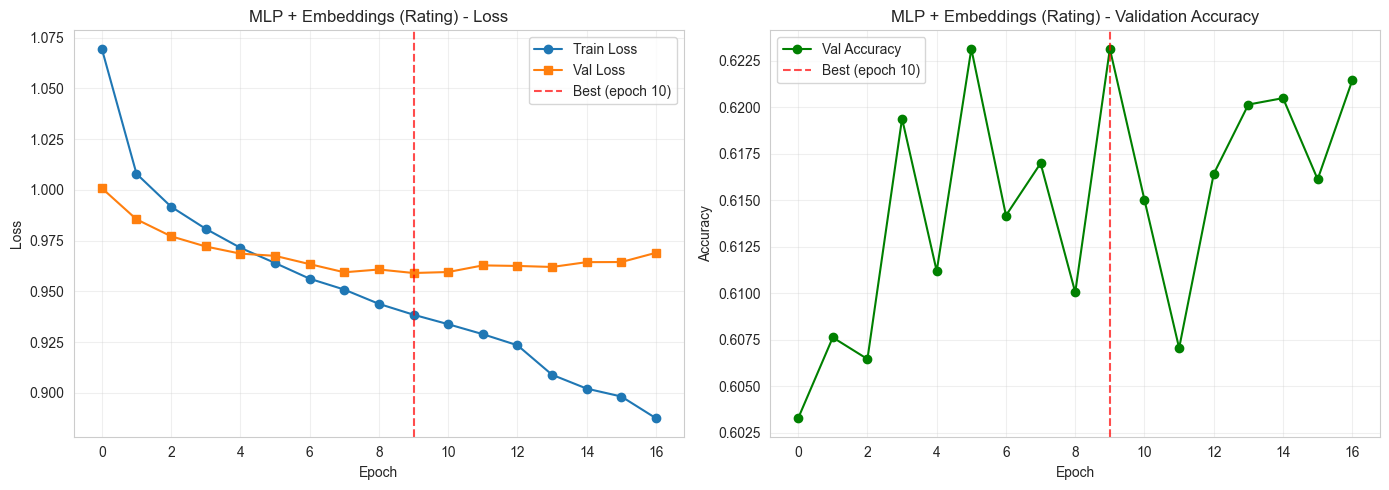


 MLP + Embeddings
Accuracy:     0.6231
F1-macro:     0.5611
F1-weighted:  0.6384

              precision    recall  f1-score   support

           1       0.78      0.73      0.75     30583
           2       0.34      0.57      0.43     15510
           3       0.37      0.41      0.39     19704
           4       0.44      0.51      0.47     41466
           5       0.85      0.69      0.76     92320

    accuracy                           0.62    199583
   macro avg       0.56      0.58      0.56    199583
weighted avg       0.67      0.62      0.64    199583



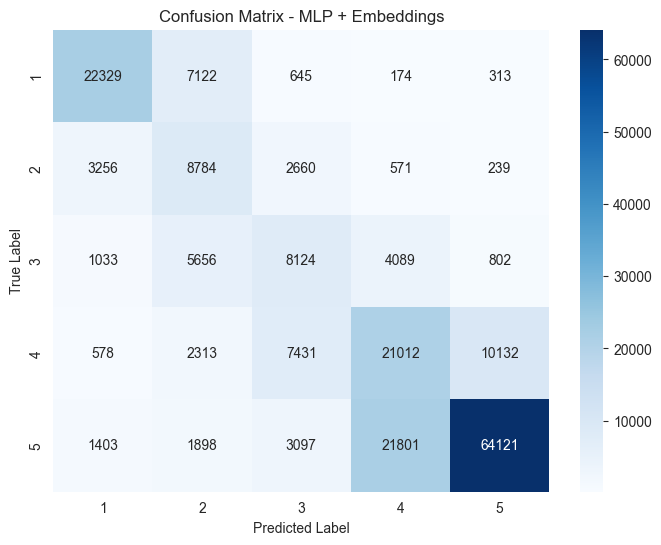

In [13]:
mlp_emb_rat = MLP(input_dim=384, n_classes=5, hidden_dims=(512, 256, 128), dropout=0.3)
print(f"Parametres : {sum(p.numel() for p in mlp_emb_rat.parameters()):,}")

history_mlp_emb_rat = train_model(
    mlp_emb_rat, train_emb_rat, test_emb_rat,
    epochs=EPOCHS_MLP, lr=1e-3, class_weights=weights_rat,
    patience=7, grad_clip=1.0, weight_decay=1e-5
)

plot_training_history(history_mlp_emb_rat, "MLP + Embeddings (Rating)")
results_rat.append(evaluate_dl_model(mlp_emb_rat, test_emb_rat, le_rating, "MLP + Embeddings"))

---
## 8. CNN (Convolutional Neural Network)

Architecture inspirée de **"Convolutional Neural Networks for Sentence Classification" (Yoon Kim, 2014)** :  
- Couche d’embedding entraînable
- Convolutions 1D multi-filtres (tailles 3, 4, 5) pour capturer les n-grammes
- Max-pooling global
- Couche fully-connected de sortie

In [14]:
# TextCNN importé depuis src.models
EMBED_DIM = 200
N_FILTERS = 256
FILTER_SIZES = (3, 4, 5)

print("Architecture TextCNN :")
print(TextCNN(VOCAB_SIZE, EMBED_DIM, 3, N_FILTERS, FILTER_SIZES))
print(f"\nParametres : {sum(p.numel() for p in TextCNN(VOCAB_SIZE, EMBED_DIM, 3, N_FILTERS, FILTER_SIZES).parameters()):,}")

Architecture TextCNN :
TextCNN(
  (embedding): Embedding(25002, 200, padding_idx=0)
  (convs): ModuleList(
    (0): Sequential(
      (0): Conv1d(200, 256, kernel_size=(3,), stride=(1,))
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (1): Sequential(
      (0): Conv1d(200, 256, kernel_size=(4,), stride=(1,))
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (2): Sequential(
      (0): Conv1d(200, 256, kernel_size=(5,), stride=(1,))
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
  )
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=768, out_features=3, bias=True)
)

Parametres : 5,619,411


### 8.1 CNN → Polarité

In [ ]:
EPOCHS_CNN = 25

cnn_pol = TextCNN(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    n_classes=3,
    n_filters=N_FILTERS,
    filter_sizes=FILTER_SIZES,
    dropout=0.5
)
print(f"Parametres : {sum(p.numel() for p in cnn_pol.parameters()):,}")

history_cnn_pol = train_model(
    cnn_pol, train_seq_pol, test_seq_pol,
    epochs=EPOCHS_CNN, lr=5e-4, class_weights=weights_pol,
    patience=5, grad_clip=1.0
)

plot_training_history(history_cnn_pol, "CNN (Polarite)")
results_pol.append(evaluate_dl_model(cnn_pol, test_seq_pol, le_polarity, "CNN"))

Parametres : 5,619,411
Epoch  1/25 | Train Loss: 0.6687 | Val Loss: 0.4583 | Val Acc: 0.8588 | LR: 5.0e-04 *


### 8.2 CNN → Rating

In [ ]:
cnn_rat = TextCNN(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    n_classes=5,
    n_filters=N_FILTERS,
    filter_sizes=FILTER_SIZES,
    dropout=0.4
)
print(f"Parametres : {sum(p.numel() for p in cnn_rat.parameters()):,}")

history_cnn_rat = train_model(
    cnn_rat, train_seq_rat, test_seq_rat,
    epochs=EPOCHS_CNN, lr=1e-3, class_weights=weights_rat,
    patience=7, grad_clip=1.0, weight_decay=1e-5
)

plot_training_history(history_cnn_rat, "CNN (Rating)")
results_rat.append(evaluate_dl_model(cnn_rat, test_seq_rat, le_rating, "CNN"))

---
## 9. Comparaison des Résultats Deep Learning

In [ ]:
# --- Résultats Polarité ---
df_pol = pd.DataFrame(results_pol).sort_values('accuracy', ascending=False)
print("\n" + "="*60)
print(" RÉSULTATS POLARITÉ (3 classes)")
print("="*60)
print(df_pol.to_string(index=False))

best_pol = df_pol.iloc[0]
print(f"\nMeilleur modèle : {best_pol['model']}")
print(f"  Accuracy: {best_pol['accuracy']:.4f} | F1-macro: {best_pol['f1_macro']:.4f}")

# --- Résultats Rating ---
df_rat = pd.DataFrame(results_rat).sort_values('accuracy', ascending=False)
print("\n" + "="*60)
print(" RÉSULTATS RATING (5 classes)")
print("="*60)
print(df_rat.to_string(index=False))

best_rat = df_rat.iloc[0]
print(f"\nMeilleur modèle : {best_rat['model']}")
print(f"  Accuracy: {best_rat['accuracy']:.4f} | F1-macro: {best_rat['f1_macro']:.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Polarité
df_pol_sorted = df_pol.sort_values('f1_macro')
colors_pol = ['#ff9999' if 'MLP' in m else '#66b3ff' for m in df_pol_sorted['model']]
axes[0].barh(df_pol_sorted['model'], df_pol_sorted['f1_macro'], color=colors_pol)
axes[0].set_title('Polarité (3 classes) - F1-Macro', fontsize=14, fontweight='bold')
axes[0].set_xlabel('F1-Macro')
axes[0].set_xlim([0, 1])
for i, v in enumerate(df_pol_sorted['f1_macro']):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)
axes[0].grid(axis='x', alpha=0.3)

# Rating
df_rat_sorted = df_rat.sort_values('f1_macro')
colors_rat = ['#ff9999' if 'MLP' in m else '#66b3ff' for m in df_rat_sorted['model']]
axes[1].barh(df_rat_sorted['model'], df_rat_sorted['f1_macro'], color=colors_rat)
axes[1].set_title('Rating (5 classes) - F1-Macro', fontsize=14, fontweight='bold')
axes[1].set_xlabel('F1-Macro')
axes[1].set_xlim([0, 1])
for i, v in enumerate(df_rat_sorted['f1_macro']):
    axes[1].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)
axes[1].grid(axis='x', alpha=0.3)

# Légende
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#ff9999', label='MLP'), Patch(facecolor='#66b3ff', label='CNN')]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, fontsize=12,
           bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/deep_learning_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : ../figures/deep_learning_comparison.png")

## 10. Comparaison avec le ML Classique (Notebook 04)

On charge les résultats du notebook 04 pour comparer ML classique vs Deep Learning.

In [ ]:
# Charger tous les résultats depuis le CSV centralisé
all_results = load_results()

if not all_results.empty:
    all_results = all_results.sort_values('f1_macro', ascending=False)
    
    print("\n" + "="*70)
    print(" COMPARAISON COMPLÈTE : ML Classique vs Deep Learning")
    print("="*70)
    print(all_results[['model', 'type', 'accuracy', 'f1_macro', 'f1_weighted']].to_string(index=False))
    
    # Visualisation
    fig, ax = plt.subplots(figsize=(14, 7))
    
    all_sorted = all_results.sort_values('f1_macro')
    colors_sorted = ['#ff9999' if t == 'ML Classique' else '#66b3ff' for t in all_sorted['type']]
    
    ax.barh(all_sorted['model'], all_sorted['f1_macro'], color=colors_sorted)
    ax.set_title('ML Classique vs Deep Learning - F1-Macro', fontsize=14, fontweight='bold')
    ax.set_xlabel('F1-Macro', fontsize=12)
    ax.set_xlim([0, 1])
    
    for i, (v, t) in enumerate(zip(all_sorted['f1_macro'], all_sorted['type'])):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#ff9999', label='ML Classique'),
        Patch(facecolor='#66b3ff', label='Deep Learning')
    ]
    ax.legend(handles=legend_elements, fontsize=11)
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    os.makedirs('../figures', exist_ok=True)
    plt.savefig('../figures/ml_vs_dl_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Graphique sauvegardé : ../figures/ml_vs_dl_comparison.png")
else:
    print("Aucun résultat trouvé. Exécutez d'abord les notebooks 04 et 05.")

## 11. Sauvegarde des Modèles et Résultats

In [ ]:
os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

# Sauvegarder les modeles PyTorch
torch.save(mlp_tfidf_pol.state_dict(), '../models/mlp_tfidf_pol.pt')
torch.save(mlp_emb_pol.state_dict(), '../models/mlp_emb_pol.pt')
torch.save(cnn_pol.state_dict(), '../models/cnn_pol.pt')
torch.save(mlp_tfidf_rat.state_dict(), '../models/mlp_tfidf_rat.pt')
torch.save(mlp_emb_rat.state_dict(), '../models/mlp_emb_rat.pt')
torch.save(cnn_rat.state_dict(), '../models/cnn_rat.pt')
print("Modeles PyTorch sauvegardes dans ../models/")

# Sauvegarder les resultats
df_pol.to_csv('../results/deep_learning_polarite_results.csv', index=False)
df_rat.to_csv('../results/deep_learning_rating_results.csv', index=False)
print("Resultats sauvegardes dans ../results/")

import pickle
with open('../models/cnn_vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)
print("Vocabulaire CNN sauvegarde : ../models/cnn_vocab.pkl")

# Metadonnees
metadata = {
    'best_polarity_model': best_pol['model'],
    'best_polarity_accuracy': float(best_pol['accuracy']),
    'best_polarity_f1_macro': float(best_pol['f1_macro']),
    'best_rating_model': best_rat['model'],
    'best_rating_accuracy': float(best_rat['accuracy']),
    'best_rating_f1_macro': float(best_rat['f1_macro']),
    'device': str(device),
    'train_size': len(X_train_text),
    'test_size': len(X_test_text),
    'mlp_max_epochs': EPOCHS_MLP,
    'cnn_max_epochs': EPOCHS_CNN,
    'batch_size': BATCH_SIZE,
    'cnn_vocab_size': VOCAB_SIZE,
    'cnn_embed_dim': EMBED_DIM,
    'cnn_n_filters': N_FILTERS,
    'cnn_max_seq_len': MAX_SEQ_LEN,
    'callbacks': ['EarlyStopping', 'ReduceLROnPlateau', 'GradientClipping', 'ModelCheckpoint'],
    'optimizer': 'AdamW (weight_decay=1e-4)',
    'class_weights_smoothing': 0.5
}

with open('../results/deep_learning_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Metadonnees sauvegardees : ../results/deep_learning_metadata.json")

## 12. Analyse des Courbes d’Entraînement

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

histories = [
    (history_mlp_tfidf_pol, "MLP+TF-IDF (Pol)"),
    (history_mlp_emb_pol, "MLP+Emb (Pol)"),
    (history_cnn_pol, "CNN (Pol)"),
    (history_mlp_tfidf_rat, "MLP+TF-IDF (Rat)"),
    (history_mlp_emb_rat, "MLP+Emb (Rat)"),
    (history_cnn_rat, "CNN (Rat)"),
]

for idx, (hist, title) in enumerate(histories):
    row, col = idx // 3, idx % 3
    ax = axes[row][col]
    
    ax.plot(hist['train_loss'], label='Train Loss', marker='o', markersize=4)
    ax.plot(hist['val_loss'], label='Val Loss', marker='s', markersize=4)
    
    ax2 = ax.twinx()
    ax2.plot(hist['val_acc'], label='Val Acc', color='green', marker='^', markersize=4, linestyle='--')
    ax2.set_ylabel('Accuracy', color='green')
    ax2.tick_params(axis='y', labelcolor='green')
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(loc='upper left', fontsize=8)
    ax2.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Courbes d\'entraînement - Tous les modèles', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/training_curves_all.png', dpi=300, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : ../figures/training_curves_all.png")

## 13. Résumé et Conclusions

### Résultats clés

| Modèle | Représentation | Avantages | Limites |
|--------|---------------|-----------|----------|
| **MLP + TF-IDF** | Vecteurs TF-IDF (5000-dim) | Simple, rapide à entraîner | Perd l’ordre des mots |
| **MLP + Embeddings** | SBERT (384-dim) | Représentation sémantique riche | Dépend du modèle pré-entraîné |
| **CNN** | Embedding entraînable + Conv1D | Capture les n-grammes locaux | Plus de paramètres, plus lent |

### Points à retenir

- Le **MLP** est un bon point de départ en Deep Learning : il montre déjà des gains par rapport au ML classique grâce à sa capacité à apprendre des non-linéarités.
- Le **CNN** capture mieux le contexte local (n-grammes) via les convolutions multi-filtres.
- La tâche de **rating (5 classes)** reste plus difficile que la **polarité (3 classes)**, les classes voisines (3 vs 4, 2 vs 3) étant souvent confondues.
- Les **poids de classes** aident à gérer le déséquilibre du dataset Yelp.